<a href="https://colab.research.google.com/github/swagatabanerjee/QML-Course-Practice/blob/main/Assignment4_Question2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Question 2 — Toffoli gate prediction**

Predict the final outcome of the described 3 qubit circuit before building it, then confirm your prediction.

**Answer**
Solution-1

1. Initial State:
      
          All qubits in |q0q1q2> = |000>

2. Apply an X gate(NOT Gate) to q0:

           flips q0 from  0 --> 1.

3. Next applying an X gate to q1:
           
           flips q1 from 0 --> 1.
           Current state: |011>.

4. Apply the Toffoli (CCNOT) Gate:
     
     The Toffoli gate flips the target qubit q2 only if both control qubits q0 and q1 are in state |1>.
     Since,
          q0 = 1 and q1 = 1, the condition is satisfied.
          q2 flips from 0 --> 1.
5. Final Prediction:
      
          Final State: |111>.
      When measured, the circuit will yield the state 111 with  near 100% probability.

In [1]:
%pip install qiskit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.7 MB/s eta 0:00:00


     ┌───┐     
q_0: ┤ X ├──■──
     ├───┤  │  
q_1: ┤ X ├──■──
     └───┘┌─┴─┐
q_2: ─────┤ X ├
          └───┘


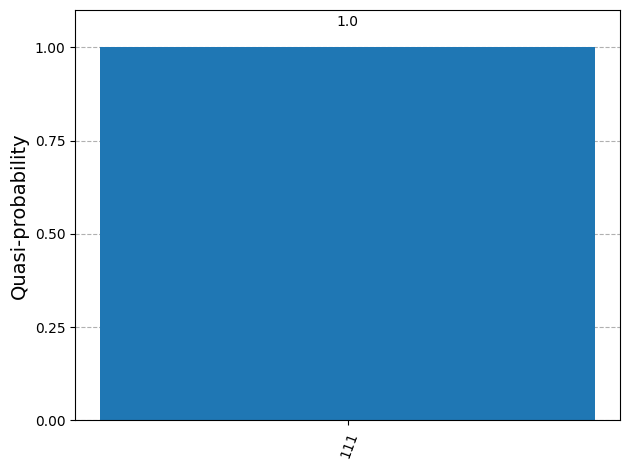

In [20]:
##Solution 1
# Initialize a circuit with 3 qubits
qc = QuantumCircuit(3)

# Apply X gates to controls (q0 and q1)
qc.x(0)
qc.x(1)

# Apply Toffoli (CCNOT) gate: controls = q0, q1; target = q2
qc.ccx(0, 1, 2)

# Verify statevector outcome
state = Statevector.from_instruction(qc)
print(qc)
plot_histogram(state.probabilities_dict())

Solution-2

1. Initial State:
      
          All qubits in |q0q1q2> = |000>

2. Apply an X gate(NOT Gate) to q0:

           flips q0 from  0 --> 1.

3. Next applying an cx gate to q1:
           
           q0 is the control qubit in state |1>,
           q1 is the target qubit in state |0>.
           Since,
            q0 = 1, q1 flips from 0 ---> 1.
            Current State: |011>

4. Apply the Toffoli (CCX) Gate:
     
     The Toffoli gate flips the target qubit q2 only if both control qubits q0 and q1 are in state |1>.
     Since,
          q0 = |1> and q1 = |1>, the condition is satisfied.
          q2 flips from 0 --> 1.
5. Final Prediction:
      
          Final State: |111>.
      When measured, the circuit will yield the state 111 with near 100% probability.

     ┌───┐          
q_0: ┤ X ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──■──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘


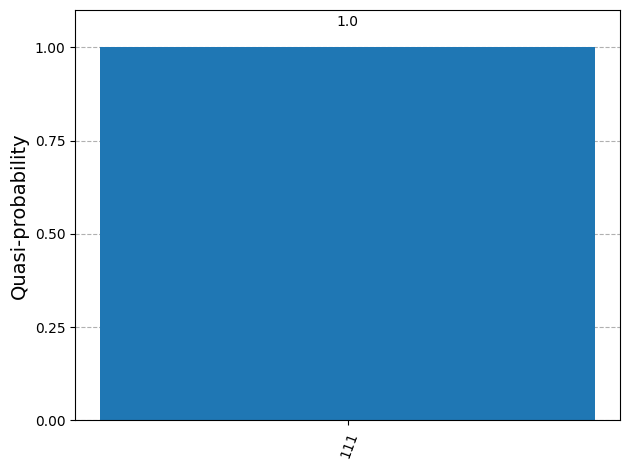

In [23]:
##Solution 2
# Initialize a circuit with 3 qubits
qc = QuantumCircuit(3)

# Apply X gate to controls q0
qc.x(0)

# Apply CX gate to controls q0 and q1
qc.cx(0,1)

# Apply Toffoli (CCNOT) gate: controls = q0, q1; target = q2
qc.ccx(0, 1, 2)

# Verify statevector outcome
state = Statevector.from_instruction(qc)
print(qc)
#print(state.draw("latex"))  # Outputs |111>
plot_histogram(state.probabilities_dict())